In [20]:
from google.colab import drive
drive.mount('/content/drive')

# Change directory to your project folder
import os
os.chdir('/content/drive/MyDrive/BCI_PROJECT/eeg_speller')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [21]:
!pip install mne numpy scipy scikit-learn matplotlib seaborn moabb
!pip install torch torchvision torchaudio
!pip install braindecode pyriemann autoreject

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from scipy.linalg import eigh
import os

os.makedirs("results", exist_ok=True)

In [23]:
from moabb.datasets import BNCI2014_009
from moabb.paradigms import P300

dataset = BNCI2014_009()
dataset.download()

paradigm = P300()
X, y, metadata = paradigm.get_data(dataset=dataset, subjects=[1])

print(f"Data shape: {X.shape}")
print(f"Classes: {np.unique(y, return_counts=True)}")
print(metadata.head())

Data shape: (1728, 16, 206)
Classes: (array(['NonTarget', 'Target'], dtype='<U9'), array([1440,  288]))
   subject session run
0        1       0   0
1        1       0   0
2        1       0   0
3        1       0   0
4        1       0   0


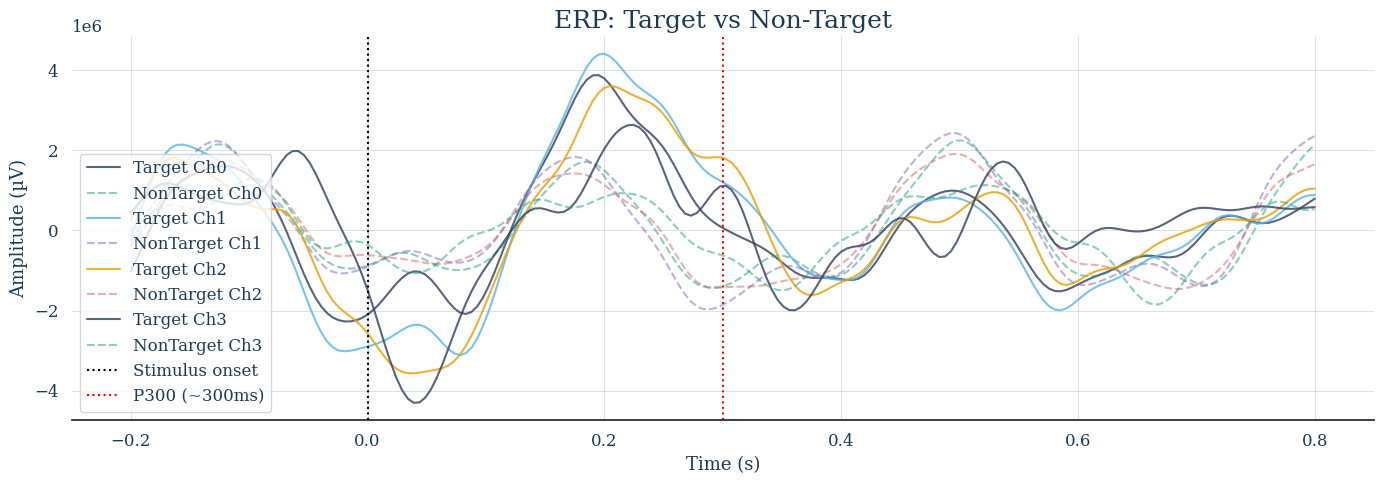

In [24]:
target_avg    = X[y == 'Target'].mean(axis=0)
nontarget_avg = X[y == 'NonTarget'].mean(axis=0)
t = np.linspace(-0.2, 0.8, X.shape[2])

plt.figure(figsize=(14, 5))
for ch in range(min(4, X.shape[1])):
    plt.plot(t, target_avg[ch] * 1e6,    label=f'Target Ch{ch}',    alpha=0.8)
    plt.plot(t, nontarget_avg[ch] * 1e6, label=f'NonTarget Ch{ch}', alpha=0.5, linestyle='--')

plt.axvline(0,   color='k', linestyle=':', label='Stimulus onset')
plt.axvline(0.3, color='r', linestyle=':', label='P300 (~300ms)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (µV)')
plt.title('ERP: Target vs Non-Target')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("results/erp_comparison.png")
plt.show()

In [25]:
def preprocess_moabb_data(X):
    n_baseline = int(X.shape[2] * 0.2)
    baseline_mean = X[:, :, :n_baseline].mean(axis=2, keepdims=True)
    X = X - baseline_mean
    std = X.std(axis=2, keepdims=True)
    std[std == 0] = 1
    X = X / std
    return X

X = preprocess_moabb_data(X)
print(f"After preprocessing: mean={X.mean():.4f}, std={X.std():.4f}")

After preprocessing: mean=-0.0944, std=1.0977


In [26]:
class XdawnFeatures:
    def __init__(self, n_components=3, n_samples=30):
        self.n_components = n_components
        self.n_samples = n_samples
        self.filters_ = None

    def fit(self, X, y):
        y_bin = np.where(y == 'Target', 1, 0)
        target_epochs = X[y_bin == 1]
        A = target_epochs.mean(axis=0)
        Sigma_s = A @ A.T
        Sigma_total = np.mean([e @ e.T for e in X], axis=0)
        eigenvalues, eigenvectors = eigh(Sigma_s, Sigma_total)
        idx = np.argsort(eigenvalues)[::-1]
        self.filters_ = eigenvectors[:, idx[:self.n_components]]
        return self

    def transform(self, X):
        X_filtered = np.tensordot(X, self.filters_, axes=([1], [0]))
        X_filtered = X_filtered.transpose(0, 2, 1)
        step = max(1, X_filtered.shape[2] // self.n_samples)
        X_filtered = X_filtered[:, :, ::step][:, :, :self.n_samples]
        return X_filtered.reshape(X_filtered.shape[0], -1)

    def fit_transform(self, X, y):
        return self.fit(X, y).transform(X)


le = LabelEncoder()
y_enc = le.fit_transform(y)

xdawn = XdawnFeatures(n_components=3, n_samples=40)
X_features = xdawn.fit_transform(X, y)
print(f"Feature matrix shape: {X_features.shape}")

Feature matrix shape: (1728, 120)


In [27]:
def calculate_itr(accuracy, n_symbols=36, trial_duration_sec=1.0):
    P = accuracy
    N = n_symbols
    if P <= 0 or P >= 1:
        return 0.0
    if P < 1.0 / N:
        return 0.0
    B = (np.log2(N) + P * np.log2(P) + (1 - P) * np.log2((1 - P) / (N - 1)))
    return max(0.0, B * 60.0 / trial_duration_sec)

In [28]:
def cross_validate_model(model, X_feat, y_enc, model_name, n_folds=5):
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
    accs, precs, recs, f1s, cms = [], [], [], [], []

    for fold, (train_idx, test_idx) in enumerate(skf.split(X_feat, y_enc)):
        X_train, X_test = X_feat[train_idx], X_feat[test_idx]
        y_train, y_test = y_enc[train_idx], y_enc[test_idx]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        accs.append(accuracy_score(y_test, y_pred))
        precs.append(precision_score(y_test, y_pred, zero_division=0))
        recs.append(recall_score(y_test, y_pred, zero_division=0))
        f1s.append(f1_score(y_test, y_pred, zero_division=0))
        cms.append(confusion_matrix(y_test, y_pred))

    mean_acc = np.mean(accs)
    print(f"\n{model_name}")
    print(f"  Accuracy:  {mean_acc:.3f} ± {np.std(accs):.3f}")
    print(f"  Precision: {np.mean(precs):.3f}")
    print(f"  Recall:    {np.mean(recs):.3f}")
    print(f"  F1:        {np.mean(f1s):.3f}")
    print(f"  ITR:       {calculate_itr(mean_acc):.1f} bits/min")

    return {"accuracy": mean_acc, "f1": np.mean(f1s),
            "itr": calculate_itr(mean_acc), "cms": cms}


lda = Pipeline([('scaler', StandardScaler()),
                ('lda', LinearDiscriminantAnalysis())])

svm = Pipeline([('scaler', StandardScaler()),
                ('svm', SVC(kernel='rbf', C=1.0, probability=True, random_state=42))])

lda_results = cross_validate_model(lda, X_features, y_enc, "LDA")
svm_results = cross_validate_model(svm, X_features, y_enc, "SVM (RBF)")


LDA
  Accuracy:  0.913 ± 0.010
  Precision: 0.760
  Recall:    0.701
  F1:        0.729
  ITR:       257.9 bits/min

SVM (RBF)
  Accuracy:  0.924 ± 0.013
  Precision: 0.851
  Recall:    0.656
  F1:        0.740
  ITR:       263.3 bits/min


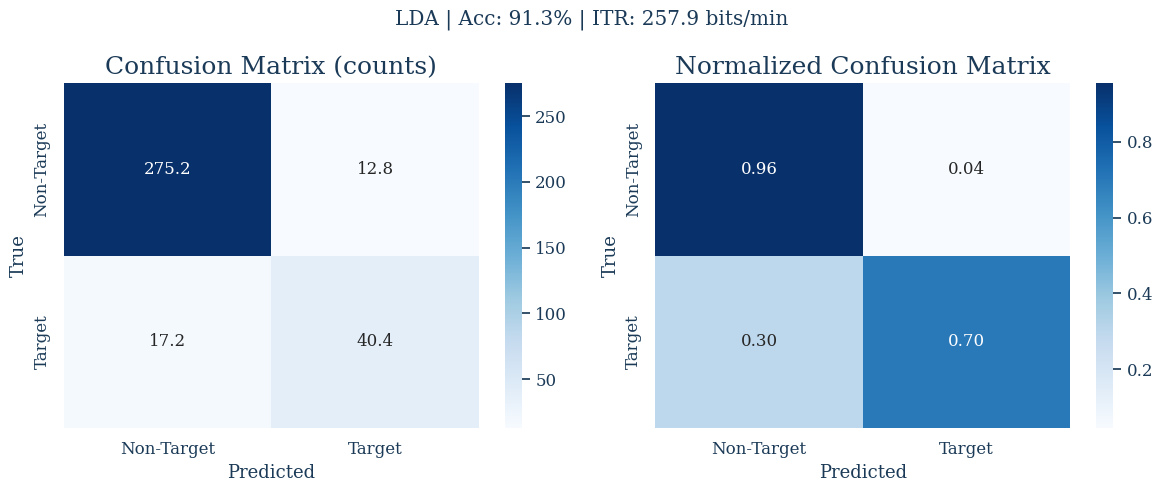

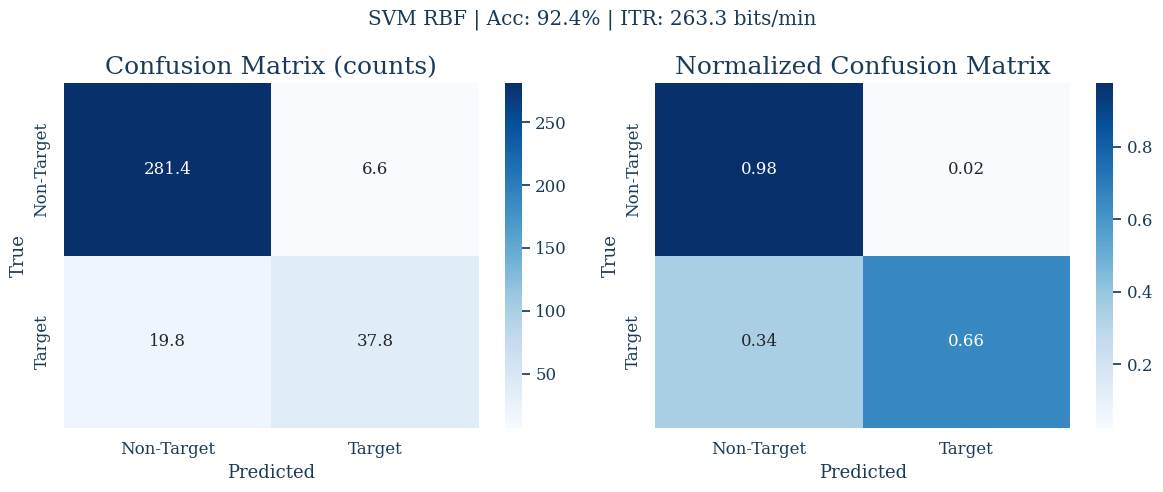

In [29]:
def plot_confusion_matrix(results, title):
    avg_cm = np.array(results["cms"]).mean(axis=0)
    avg_cm_norm = avg_cm / avg_cm.sum(axis=1, keepdims=True)
    class_names = ['Non-Target', 'Target']

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    sns.heatmap(avg_cm, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=axes[0])
    axes[0].set_title('Confusion Matrix (counts)')
    axes[0].set_ylabel('True')
    axes[0].set_xlabel('Predicted')

    sns.heatmap(avg_cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=axes[1])
    axes[1].set_title('Normalized Confusion Matrix')
    axes[1].set_ylabel('True')
    axes[1].set_xlabel('Predicted')

    plt.suptitle(f"{title} | Acc: {results['accuracy']:.1%} | ITR: {results['itr']:.1f} bits/min")
    plt.tight_layout()
    plt.savefig(f"results/cm_{title.replace(' ', '_')}.png")
    plt.show()

plot_confusion_matrix(lda_results, "LDA")
plot_confusion_matrix(svm_results, "SVM RBF")

In [30]:
class EEGNet(nn.Module):
    def __init__(self, n_channels=16, n_timepoints=256, n_classes=2,
                 F1=8, D=2, F2=16, dropout_rate=0.5):
        super(EEGNet, self).__init__()

        self.temporal_conv = nn.Sequential(
            nn.Conv2d(1, F1, kernel_size=(1, 64), padding=(0, 32), bias=False),
            nn.BatchNorm2d(F1)
        )
        self.spatial_conv = nn.Sequential(
            nn.Conv2d(F1, F1 * D, kernel_size=(n_channels, 1), groups=F1, bias=False),
            nn.BatchNorm2d(F1 * D),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1, 4)),
            nn.Dropout(dropout_rate)
        )
        self.separable_conv = nn.Sequential(
            nn.Conv2d(F1 * D, F1 * D, kernel_size=(1, 16), padding=(0, 8), groups=F1 * D, bias=False),
            nn.Conv2d(F1 * D, F2, kernel_size=(1, 1), bias=False),
            nn.BatchNorm2d(F2),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1, 8)),
            nn.Dropout(dropout_rate)
        )

        flatten_size = self._get_flatten_size(n_channels, n_timepoints)
        self.classifier = nn.Linear(flatten_size, n_classes)

    def _get_flatten_size(self, n_channels, n_timepoints):
        dummy = torch.zeros(1, 1, n_channels, n_timepoints)
        x = self.temporal_conv(dummy)
        x = self.spatial_conv(x)
        x = self.separable_conv(x)
        return x.numel()

    def forward(self, x):
        x = self.temporal_conv(x)
        x = self.spatial_conv(x)
        x = self.separable_conv(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

In [31]:
def train_eegnet(X, y, n_folds=5, n_epochs=50, batch_size=32, lr=1e-3):
    le = LabelEncoder()
    y_enc = le.fit_transform(y)
    n_channels, n_timepoints = X.shape[1], X.shape[2]
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
    fold_accs = []

    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y_enc)):
        print(f"\n--- Fold {fold+1}/{n_folds} ---")
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y_enc[train_idx], y_enc[test_idx]

        X_tr = torch.FloatTensor(X_train[:, np.newaxis, :, :]).to(device)
        y_tr = torch.LongTensor(y_train).to(device)
        X_te = torch.FloatTensor(X_test[:, np.newaxis,  :, :]).to(device)

        loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=batch_size, shuffle=True)

        model = EEGNet(n_channels=n_channels, n_timepoints=n_timepoints).to(device)

        n_target = y_train.sum()
        n_nontarget = len(y_train) - n_target
        weight = torch.FloatTensor([1.0, n_nontarget / max(n_target, 1)]).to(device)
        criterion = nn.CrossEntropyLoss(weight=weight)
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
        scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)

        model.train()
        for epoch in range(n_epochs):
            total_loss = 0
            for xb, yb in loader:
                optimizer.zero_grad()
                loss = criterion(model(xb), yb)
                loss.backward()
                optimizer.step()
                total_loss += loss.item()
            scheduler.step()
            if (epoch + 1) % 10 == 0:
                print(f"  Epoch {epoch+1}/{n_epochs} | Loss: {total_loss/len(loader):.4f}")

        model.eval()
        with torch.no_grad():
            preds = model(X_te).argmax(dim=1).cpu().numpy()

        acc = accuracy_score(y_test, preds)
        fold_accs.append(acc)
        print(f"  Fold {fold+1} Accuracy: {acc:.3f}")

    mean_acc = np.mean(fold_accs)
    print(f"\nEEGNet Final: {mean_acc:.3f} ± {np.std(fold_accs):.3f} | ITR: {calculate_itr(mean_acc):.1f} bits/min")
    return mean_acc

eegnet_acc = train_eegnet(X, y)

Using device: cuda

--- Fold 1/5 ---
  Epoch 10/50 | Loss: 0.3276
  Epoch 20/50 | Loss: 0.2928
  Epoch 30/50 | Loss: 0.2694
  Epoch 40/50 | Loss: 0.2427
  Epoch 50/50 | Loss: 0.2687
  Fold 1 Accuracy: 0.870

--- Fold 2/5 ---
  Epoch 10/50 | Loss: 0.3284
  Epoch 20/50 | Loss: 0.2862
  Epoch 30/50 | Loss: 0.2453
  Epoch 40/50 | Loss: 0.2494
  Epoch 50/50 | Loss: 0.2613
  Fold 2 Accuracy: 0.867

--- Fold 3/5 ---
  Epoch 10/50 | Loss: 0.3983
  Epoch 20/50 | Loss: 0.3247
  Epoch 30/50 | Loss: 0.3121
  Epoch 40/50 | Loss: 0.2924
  Epoch 50/50 | Loss: 0.2911
  Fold 3 Accuracy: 0.870

--- Fold 4/5 ---
  Epoch 10/50 | Loss: 0.3990
  Epoch 20/50 | Loss: 0.3100
  Epoch 30/50 | Loss: 0.3027
  Epoch 40/50 | Loss: 0.2686
  Epoch 50/50 | Loss: 0.2607
  Fold 4 Accuracy: 0.890

--- Fold 5/5 ---
  Epoch 10/50 | Loss: 0.3517
  Epoch 20/50 | Loss: 0.2665
  Epoch 30/50 | Loss: 0.2639
  Epoch 40/50 | Loss: 0.2585
  Epoch 50/50 | Loss: 0.2542
  Fold 5 Accuracy: 0.878

EEGNet Final: 0.875 ± 0.008 | ITR: 239.1

In [32]:
print("\n" + "="*55)
print(f"{'Model':<20} {'Accuracy':>10} {'ITR (bits/min)':>15}")
print("="*55)
print(f"{'LDA':<20} {lda_results['accuracy']:>10.3f} {lda_results['itr']:>15.1f}")
print(f"{'SVM (RBF)':<20} {svm_results['accuracy']:>10.3f} {svm_results['itr']:>15.1f}")
print(f"{'EEGNet':<20} {eegnet_acc:>10.3f} {calculate_itr(eegnet_acc):>15.1f}")
print("="*55)


Model                  Accuracy  ITR (bits/min)
LDA                       0.913           257.9
SVM (RBF)                 0.924           263.3
EEGNet                    0.875           239.1
